In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering


In [9]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    image_path = fn

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


Saving istockphoto-480931380-612x612.jpg to istockphoto-480931380-612x612 (1).jpg


In [10]:
image_small = cv2.resize(image, (150, 150))
pixels = image_small.reshape(-1, 3)


In [11]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(pixels)
cluster_centers = np.uint8(kmeans.cluster_centers_)
segmented_kmeans = cluster_centers[kmeans_labels].reshape(image_small.shape)


In [12]:
agglo = AgglomerativeClustering(n_clusters=k)
agglo_labels = agglo.fit_predict(pixels)
segmented_hier = np.zeros_like(pixels)
for i in range(k):
    segmented_hier[agglo_labels == i] = np.mean(pixels[agglo_labels == i], axis=0)
segmented_hier = segmented_hier.reshape(image_small.shape).astype(np.uint8)


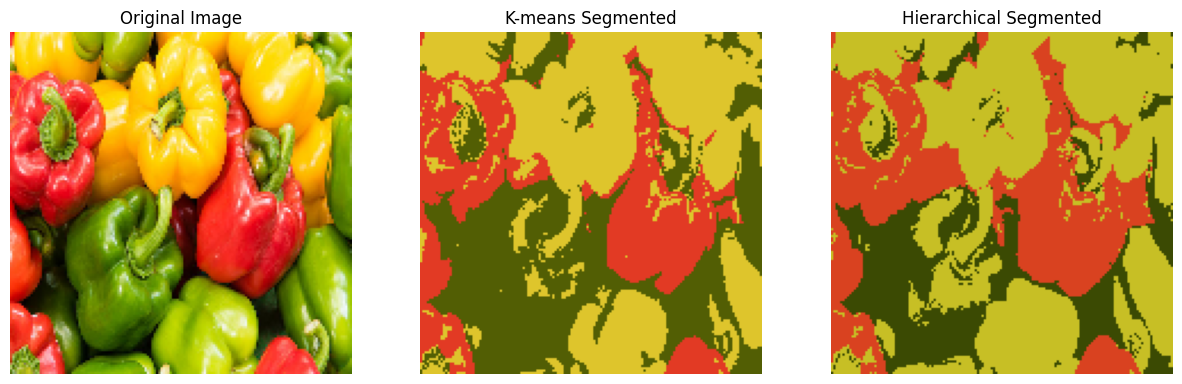

In [13]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(image_small)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(segmented_kmeans)
plt.title('K-means Segmented')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(segmented_hier)
plt.title('Hierarchical Segmented')
plt.axis('off')
plt.show()
